In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
((1.96 * np.sqrt(463))/1)**2

1778.6607999999999

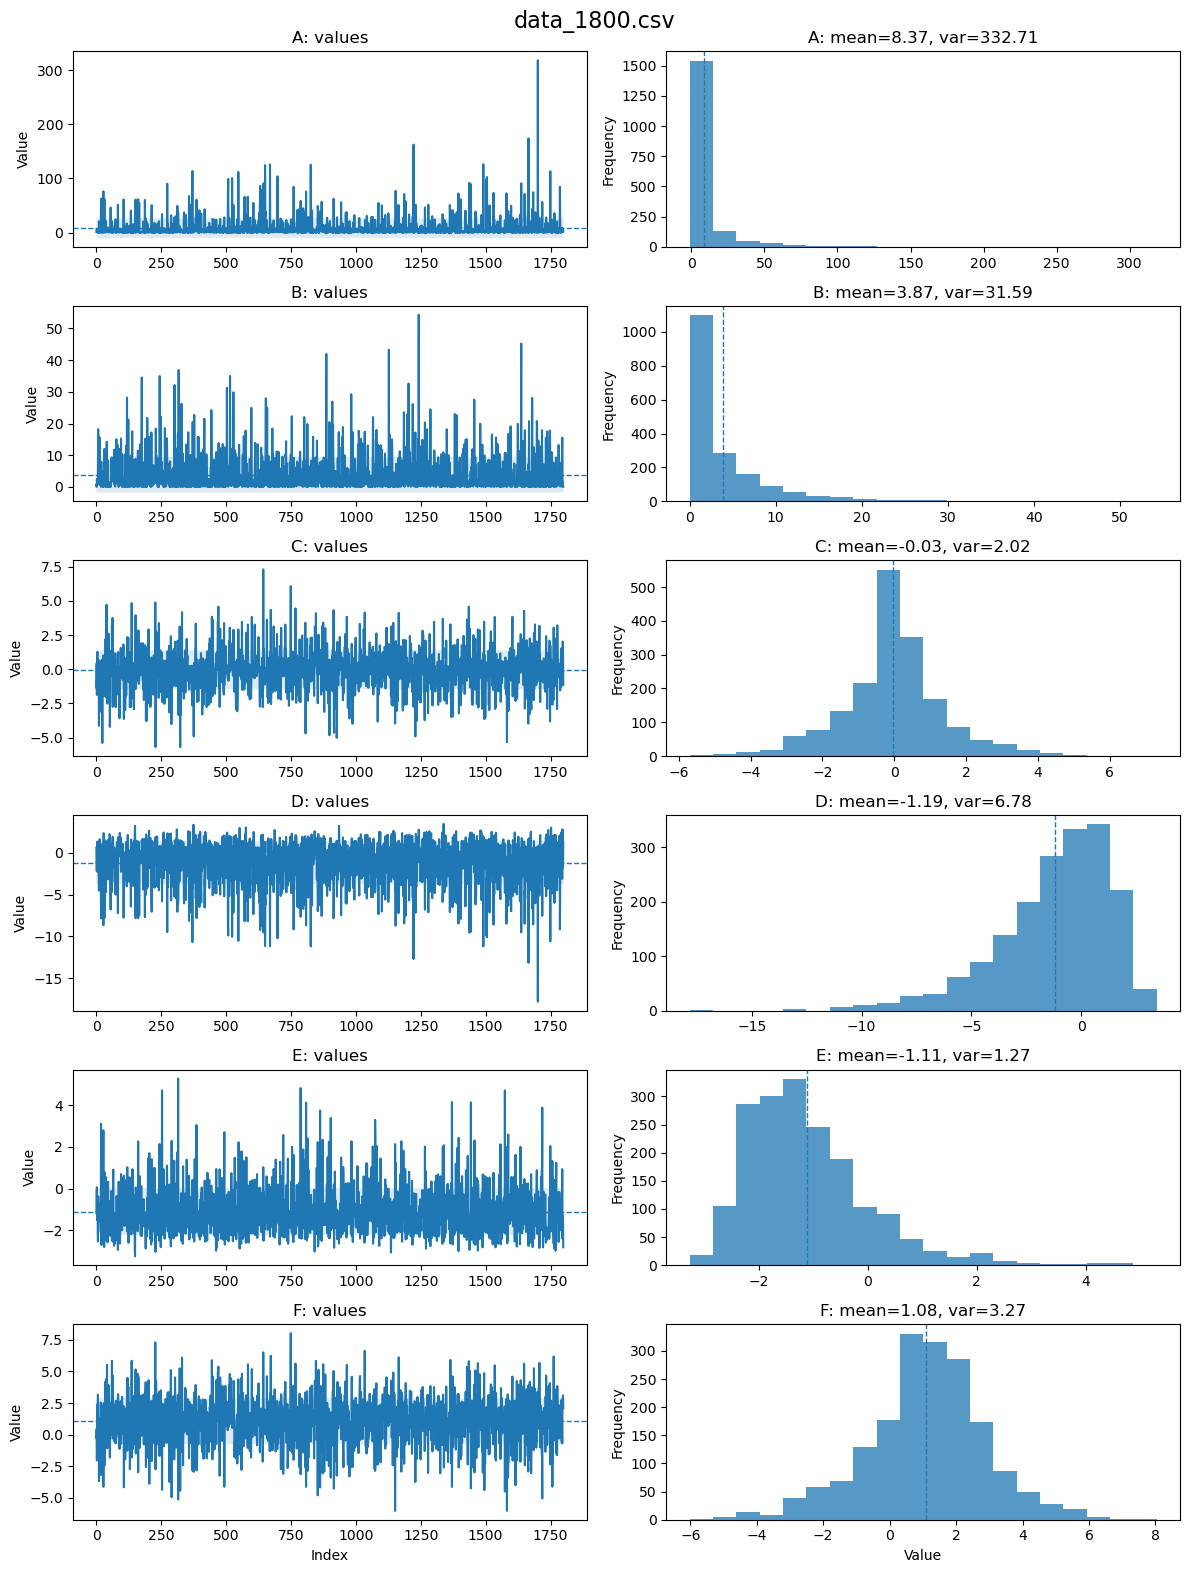

In [3]:
import numpy as np
import matplotlib.pyplot as plt

filename = "data_1800.csv"

data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 2, 3, 4, 5, 6)
)

names = ["A", "B", "C", "D", "E", "F"]
x = np.arange(data.shape[0])

fig, axes = plt.subplots(6, 2, figsize=(12, 16))

for i, name in enumerate(names):
    y = data[:, i]

    mean = np.mean(y)
    var = np.var(y)
    std = np.sqrt(var)

    # Left: variable values
    axes[i, 0].plot(x, y)
    axes[i, 0].axhline(mean, linestyle="--", linewidth=1)
    axes[i, 0].fill_between(x, mean - std, mean + std, alpha=0.15)
    axes[i, 0].set_title(f"{name}: values")
    axes[i, 0].set_ylabel("Value")

    # Right: distribution
    axes[i, 1].hist(y, bins=20, alpha=0.75)
    axes[i, 1].axvline(mean, linestyle="--", linewidth=1)
    axes[i, 1].set_title(f"{name}: mean={mean:.2f}, var={var:.2f}")
    axes[i, 1].set_ylabel("Frequency")

axes[-1, 0].set_xlabel("Index")
axes[-1, 1].set_xlabel("Value")

fig.suptitle(f"{filename}", fontsize=16)
plt.tight_layout()
plt.show()


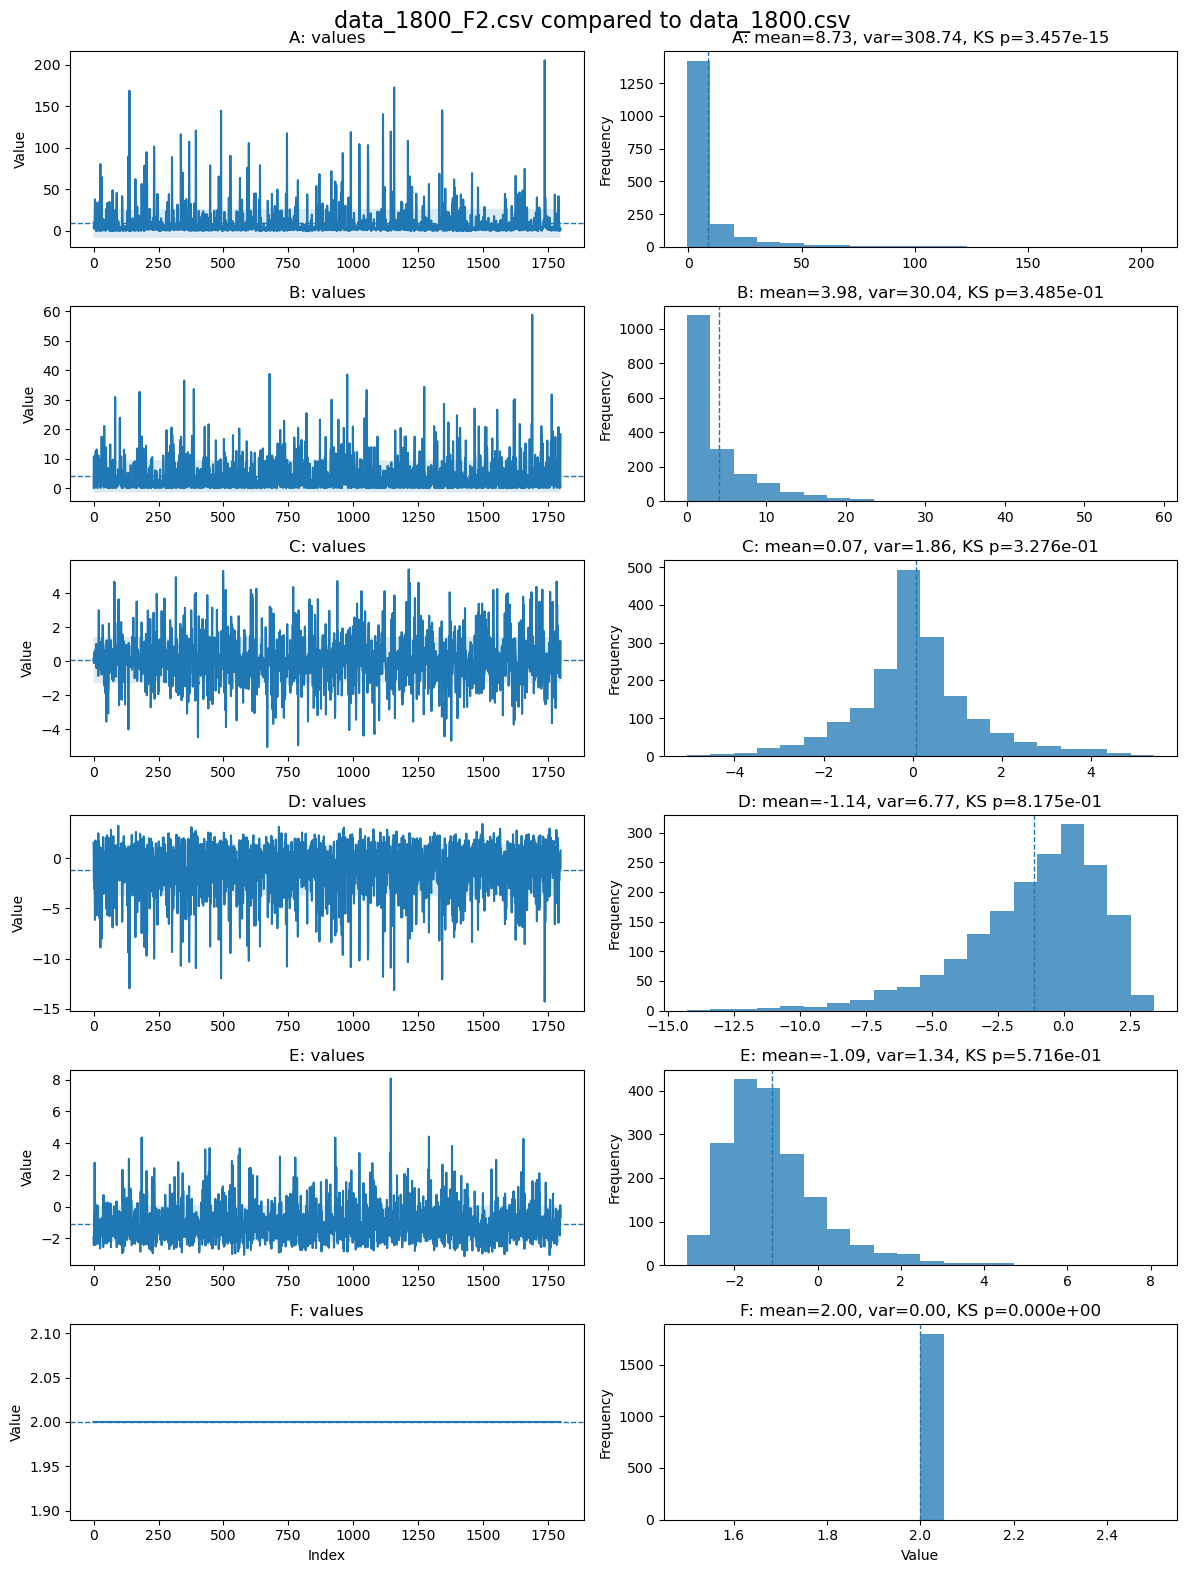

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

file_original = "data_1800.csv"
file_second = "data_1800_F2.csv" 

names = ["A", "B", "C", "D", "E", "F"]

data1 = np.genfromtxt(
    file_original,
    delimiter=",",
    skip_header=1,
    usecols=(1, 2, 3, 4, 5, 6)
)

data2 = np.genfromtxt(
    file_second,
    delimiter=",",
    skip_header=1,
    usecols=(1, 2, 3, 4, 5, 6)
)

x = np.arange(data2.shape[0])

fig, axes = plt.subplots(6, 2, figsize=(12, 16))

for i, name in enumerate(names):
    y_orig = data1[:, i]
    y_new = data2[:, i]

    mean = np.mean(y_new)
    var = np.var(y_new)
    std = np.sqrt(var)

    # KS test: original variable vs second variable
    ksŒ_stat, p_value = stats.ks_2samp(y_orig, y_new)

    # Left: variable values from second file
    axes[i, 0].plot(x, y_new)
    axes[i, 0].axhline(mean, linestyle="--", linewidth=1)
    axes[i, 0].fill_between(x, mean - std, mean + std, alpha=0.15)
    axes[i, 0].set_title(f"{name}: values")
    axes[i, 0].set_ylabel("Value")

    # Right: distribution from second file + p-value vs original
    axes[i, 1].hist(y_new, bins=20, alpha=0.75)
    axes[i, 1].axvline(mean, linestyle="--", linewidth=1)
    axes[i, 1].set_title(
        f"{name}: mean={mean:.2f}, var={var:.2f}, KS p={p_value:.3e}"
    )
    axes[i, 1].set_ylabel("Frequency")

axes[-1, 0].set_xlabel("Index")
axes[-1, 1].set_xlabel("Value")

fig.suptitle(f"{file_second} compared to {file_original}", fontsize=16)
plt.tight_layout()
plt.show()

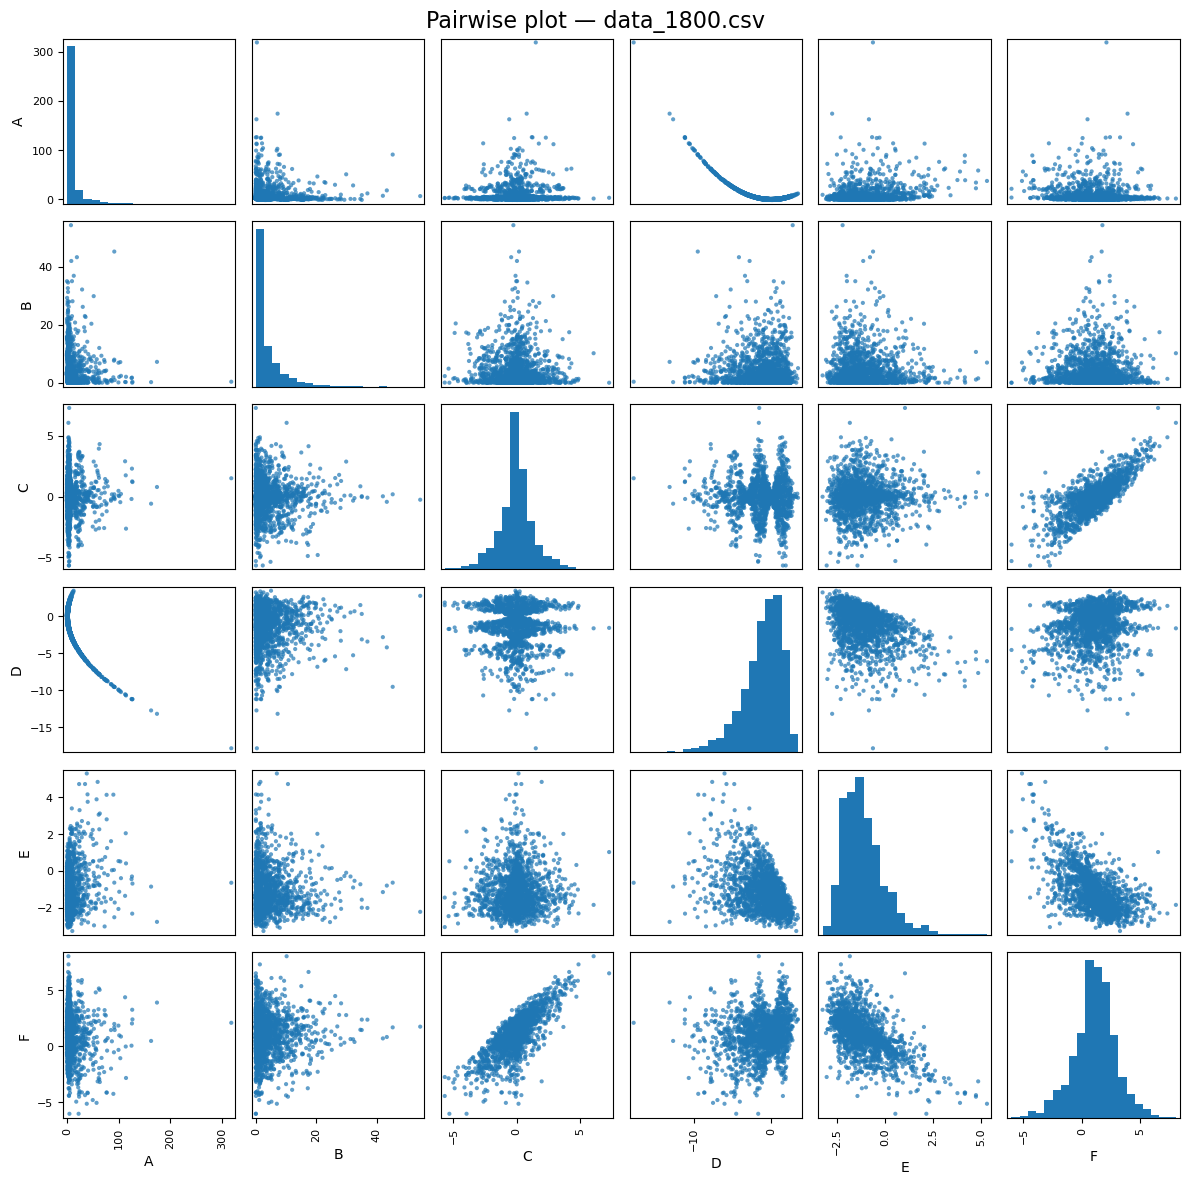

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix

filename = "data_1800.csv"

data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 2, 3, 4, 5, 6)
)

names = ["A", "B", "C", "D", "E", "F"]
x = np.arange(data.shape[0])

# Pairwise plot
df = pd.DataFrame(data, columns=names)

scatter_matrix(
    df,
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.7,
    hist_kwds={"bins": 20}
)

plt.suptitle(f"Pairwise plot — {filename}", fontsize=16)
plt.tight_layout()
plt.show()

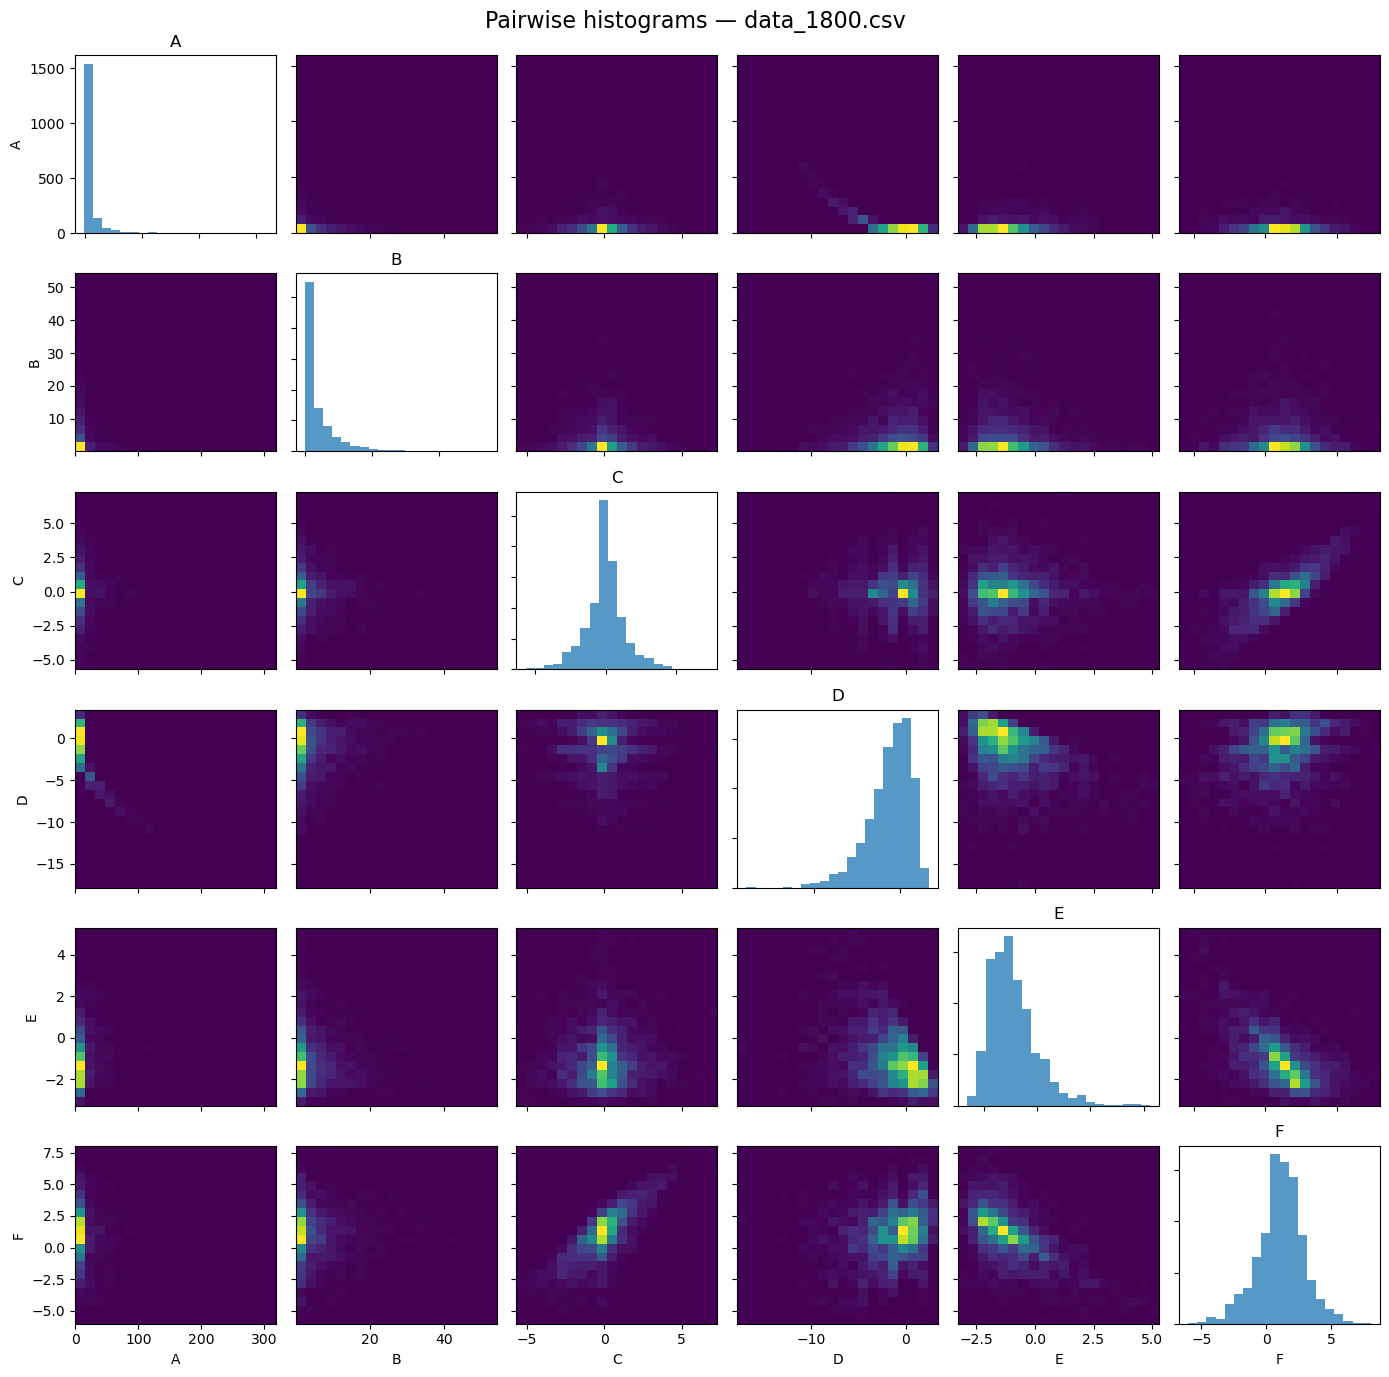

In [6]:
# Pairwise 2D histograms
df = pd.DataFrame(data, columns=names)

n = len(names)
fig, axes = plt.subplots(n, n, figsize=(14, 14))

bins = 20

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            ax.hist(df[names[i]], bins=bins, alpha=0.75)
            ax.set_title(names[i])
        else:
            h = ax.hist2d(
                df[names[j]],
                df[names[i]],
                bins=bins
            )

        if i == n - 1:
            ax.set_xlabel(names[j])
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(names[i])
        else:
            ax.set_yticklabels([])

fig.suptitle(f"Pairwise histograms — {filename}", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# Correlation matrix
corr = df.corr(method="pearson")

print("Pearson correlation matrix:")
print(corr.round(3))

Pearson correlation matrix:
       A      B      C      D      E      F
A  1.000 -0.006  0.042 -0.793  0.222 -0.103
B -0.006  1.000 -0.029 -0.011 -0.014 -0.008
C  0.042 -0.029  1.000 -0.046  0.029  0.768
D -0.793 -0.011 -0.046  1.000 -0.409  0.218
E  0.222 -0.014  0.029 -0.409  1.000 -0.604
F -0.103 -0.008  0.768  0.218 -0.604  1.000
